In [28]:
import xtrack as xt
import numpy as np
import os
import matplotlib.pyplot  as plt
import matplotlib.patches as patches
import xpart as xp
import xobjects as xo
import math
from TuneDiagram.lib.TuneDiagram.tune_diagram import resonance_lines
from prettytable import PrettyTable


Safe Working Point 1: Qx: 14.937, Qy: 14.608
Safe Working Point 2: Qx: 14.608, Qy: 14.937
Safe Working Point 3: Qx: 14.532, Qy: 14.696
Safe Working Point 4: Qx: 14.696, Qy: 14.532
Safe Working Point 5: Qx: 14.892, Qy: 14.525


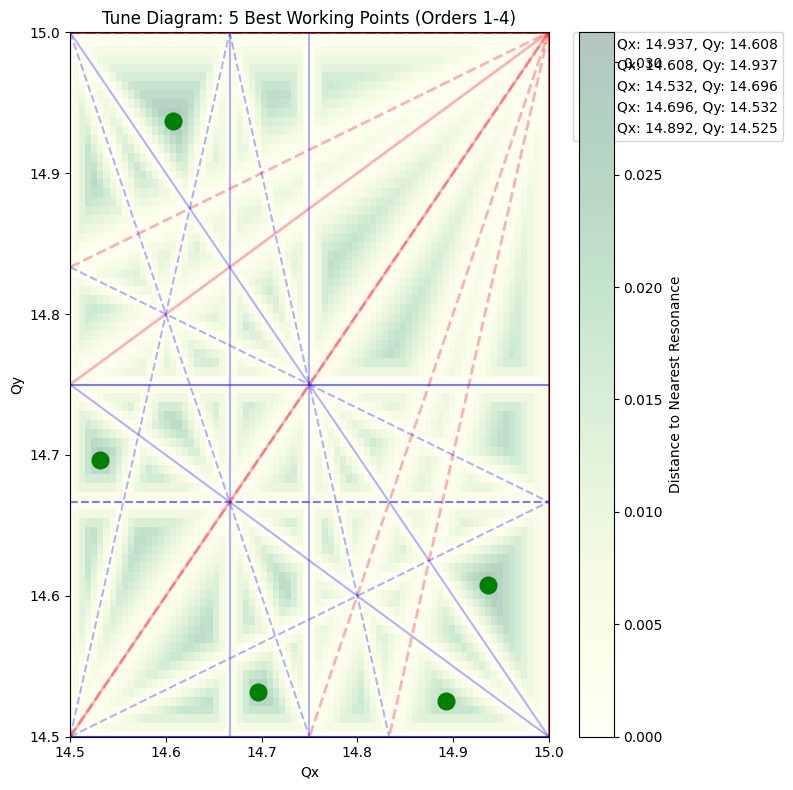

In [29]:
class resonance_lines(object):
    def __init__(self, Qx_range, Qy_range, orders, periodicity):
        # Determine the plotting bounds
        if np.std(Qx_range):
            self.Qx_min, self.Qx_max = np.min(Qx_range), np.max(Qx_range)
        else:
            self.Qx_min, self.Qx_max = np.floor(Qx_range)-0.05, np.floor(Qx_range)+1.05
            
        if np.std(Qy_range):
            self.Qy_min, self.Qy_max = np.min(Qy_range), np.max(Qy_range)
        else:
            self.Qy_min, self.Qy_max = np.floor(Qy_range)-0.05, np.floor(Qy_range)+1.05

        self.periodicity = periodicity
                                    
        nx, ny = [], []
        for order in np.nditer(np.array(orders)):
            t = np.array(range(-order, order+1))
            nx.extend(order - np.abs(t))
            ny.extend(t)
        
        nx, ny = np.array(nx), np.array(ny)
        
        # Calculate possible sums (S) that cross our tune window
        cextr = np.array([nx*np.floor(self.Qx_min)+ny*np.floor(self.Qy_min),
                          nx*np.ceil(self.Qx_max)+ny*np.floor(self.Qy_min),
                          nx*np.floor(self.Qx_min)+ny*np.ceil(self.Qy_max),
                          nx*np.ceil(self.Qx_max)+ny*np.ceil(self.Qy_max)], dtype='int')
        
        cmin = np.min(cextr, axis=0)
        cmax = np.max(cextr, axis=0)
        res_sum = [range(cmin[i], cmax[i]+1) for i in range(cextr.shape[1])]                                
        
        # Fix: Store as a list so we can iterate multiple times
        self.resonance_list = list(zip(nx, ny, res_sum))

    def plot_resonance(self, figure_object=None):
        if figure_object:
            fig = figure_object
            plt.figure(fig.number)
        else:
            fig = plt.figure(figsize=(8, 8))
            
        plt.xlim(self.Qx_min, self.Qx_max)
        plt.ylim(self.Qy_min, self.Qy_max)
        plt.xlabel('Qx')
        plt.ylabel('Qy')        
        
        for nx, ny, res_sums in self.resonance_list:
            for s in res_sums:        
                if ny != 0:
                    line, = plt.plot([self.Qx_min, self.Qx_max], 
                                     [(s - nx * self.Qx_min) / ny, (s - nx * self.Qx_max) / ny], 
                                     alpha=0.3)
                elif nx != 0:
                    line, = plt.plot([float(s)/nx, float(s)/nx], [self.Qy_min, self.Qy_max], alpha=0.3)
                
                if ny % 2:
                    plt.setp(line, linestyle='--')
                if s % self.periodicity:
                    plt.setp(line, color='b')
                else:
                    plt.setp(line, color='r', linewidth=2.0)
        return fig

    def get_safe_score(self, qx, qy):
        distances = []
        for nx, ny, res_sums in self.resonance_list:
            if nx == 0 and ny == 0: 
                continue
            for s in res_sums:
                # Euclidean distance to the line nx*Qx + ny*Qy = s
                dist = abs(nx*qx + ny*qy - s) / np.sqrt(nx**2 + ny**2)
                # Penalize systematic resonances (red lines)
                if s % self.periodicity == 0:
                    dist /= 2.0 
                distances.append(dist)
        return min(distances) if distances else 1.0

# --- MAIN EXECUTION BLOCK ---
# 1. Initialize parameters
resonance_orders = (1, 2, 3, 4)
qx_range = (14.5, 15)
qy_range = (14.5, 15)
p = 3

res = resonance_lines(qx_range, qy_range, resonance_orders, p)

# 2. Create the safety heatmap grid
# (Reduce 100 to 50 if it runs too slowly)
grid_size = 80 
qx_vals = np.linspace(14.5, 15, grid_size)
qy_vals = np.linspace(14.5, 15, grid_size)
scores = np.zeros((grid_size, grid_size))

for i, x in enumerate(qx_vals):
    for j, y in enumerate(qy_vals):
        scores[j, i] = res.get_safe_score(x, y)

# 3. Setup Plot
fig, ax = plt.subplots(figsize=(8, 8))
res.plot_resonance(fig)

# 4. Overlay Heatmap
mesh = ax.pcolormesh(qx_vals, qy_vals, scores, cmap='YlGn', alpha=0.3, shading='auto')
plt.colorbar(mesh, label='Distance to Nearest Resonance')

# 5. Find and Plot the 5 Best Points
flat_indices = np.argsort(scores.ravel())[::-1] # Sort descending
best_pts = []
for idx in flat_indices:
    iy, ix = np.unravel_index(idx, scores.shape)
    candidate = (qx_vals[ix], qy_vals[iy])
    
    # Ensure points aren't too close to each other (spatial filtering)
    if all(np.sqrt((candidate[0]-p[0])**2 + (candidate[1]-p[1])**2) > 0.05 for p in best_pts):
        best_pts.append(candidate)
        
        # Using candidate[0] and [1] ensures the label matches the plotted point
        label_text = f'Qx: {candidate[0]:.3f}, Qy: {candidate[1]:.3f}'
        
        ax.plot(candidate[0], candidate[1], 'o', markersize=12, 
                color='green', label=label_text)
        
        print(f"Safe Working Point {len(best_pts)}: {label_text}")
    
    if len(best_pts) >= 5:
        break

plt.title(f"Tune Diagram: 5 Best Working Points (Orders 1-{max(resonance_orders)})")
# Place the legend outside the plot so it doesn't cover the resonance lines
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout() # Adjusts layout to make room for the legend
plt.show()

In [30]:
#Pre-defined params
# %% create environment, parameters and first simple cells & structures
#reupload

pdr = xt.Environment()
pdr.particle_ref = xt.Particles(kinetic_energy0=2.86e9, mass0 = xt.ELECTRON_MASS_EV)

E0 = 2.86e9; VRF = 2.000e6 # beam energy in eV and RF voltage (1 cavity) in V

pdr.vars({ 
'l_cell':   3.5000,
'l_bend':   0.4000,
'l_bendDS':   0.5500,
'dl_noben':   0.2500,
'l_quad':   0.3000,
'l_drift':   0.5250,
'dl_drift':  -0.1500,
'dl_trans':   0.0000,
'l_doub':   0.2500,
'l_tripl':   3.0000,
'l_trips':   0.4000,
'N_cells_S':   8.0000,
'hBarc':   0.1507,
'kQFarc':   2.8579,
'kQDarc':  -2.8333,
'kQFarcM':   2.7633,
'kQDarcM':  -3.1990,
'kQFDS':   2.8473,
'kQDDS':  -2.5869,
'kQFDoub':   3.7011,
'kQDDoub':  -2.3242,
'kQFtr':   4.1683,
'kQDtr':  -2.5106,
'l_sext':   0.1000,
'kSF':  80.5236,
'kSD': -114.8259,})

pdr.vars({'N_cells_S': 8,'hBarc' : '6.283185307/(6*(2*N_cells_S*l_bend + l_bendDS))',
  'kQFarc': 2.9478, 'kQDarc':-2.9231,'kQFarcM': 2.8846, 'kQDarcM':-2.7567, 
  'kQFDS': 2.8042, 'kQDDS':-2.2858, 'kQFDoub': 3.9170, 'kQDDoub':-2.5190, 
  'kQFtr': 4.4429, 'kQDtr':-2.4723 } )

U0 = (0.88463e-31)*E0**4*(2.*np.pi)/(6*(2*pdr['N_cells_S']*pdr['l_bend'] + pdr['l_bendDS']) )

pdr.new('Bend', xt.Bend, length='l_bend', angle='hBarc*l_bend', k0_from_h=True, 
         edge_entry_angle='hBarc*l_bend/2', edge_exit_angle='hBarc*l_bend/2')
pdr.new('QFarc',  xt.Quadrupole, length='l_quad',    k1='kQFarc' )
pdr.new('QFarcH', xt.Quadrupole, length='l_quad/2.', k1='kQFarc' )
pdr.new('Drarc',  xt.Drift,      length='l_drift' )
pdr.new('DrarcS', xt.Drift,      length='l_drift + dl_drift' )
pdr.new('QDarc',  xt.Quadrupole, length='l_quad',    k1='kQDarc' )
pdr.new('QFarcM', xt.Quadrupole, length='l_quad',    k1='kQFarcM' )
pdr.new('QDarcM', xt.Quadrupole, length='l_quad',    k1='kQDarcM' )
pdr.new('BendDS', xt.Bend, length='l_bendDS', angle='hBarc*l_bendDS', k0_from_h=True, 
         edge_entry_angle='hBarc*l_bendDS/2', edge_exit_angle='hBarc*l_bendDS/2')
pdr.new('QFDS',   xt.Quadrupole, length='l_quad',    k1='kQFDS' )
pdr.new('QDDS',   xt.Quadrupole, length='l_quad',    k1='kQDDS' )
pdr.new('DrDSL',  xt.Drift,      length='2*l_drift + l_bend + dl_noben' )
pdr.new('DrTrans',xt.Drift,      length='l_drift + dl_trans' )
pdr.new('QFDoub', xt.Quadrupole, length='l_quad',    k1='kQFDoub' )
pdr.new('QDDoub', xt.Quadrupole, length='l_quad',    k1='kQDDoub' )
pdr.new('DrDoub', xt.Drift,      length='l_doub' )

pdr.new('QFtr',    xt.Quadrupole, length='l_quad',    k1='kQFtr' )
pdr.new('QFtrH',   xt.Quadrupole, length='l_quad/2.', k1='kQFtr' )
pdr.new('QDtr',    xt.Quadrupole, length='l_quad',    k1='kQDtr' )
pdr.new('QDtrH',   xt.Quadrupole, length='l_quad',    k1='kQDtr' )
pdr.new('DrTripl', xt.Drift,      length='l_tripl' )
pdr.new('DrTrips', xt.Drift,      length='l_trips' )

#Add any new variables and structures here


pdr.new('Drarc2', xt.Drift, length='(l_drift-l_sext)/2')
pdr.new('Drarc3', xt.Drift, length='((l_drift-l_sext)/2)+l_sext')
pdr.new('SFDS', xt.Sextupole, length='l_sext',k2='kSF')
pdr.new('SDDS', xt.Sextupole, length='l_sext',k2='kSD')

pdr['l_tripl']=2.7

3.5
3.5
4.4


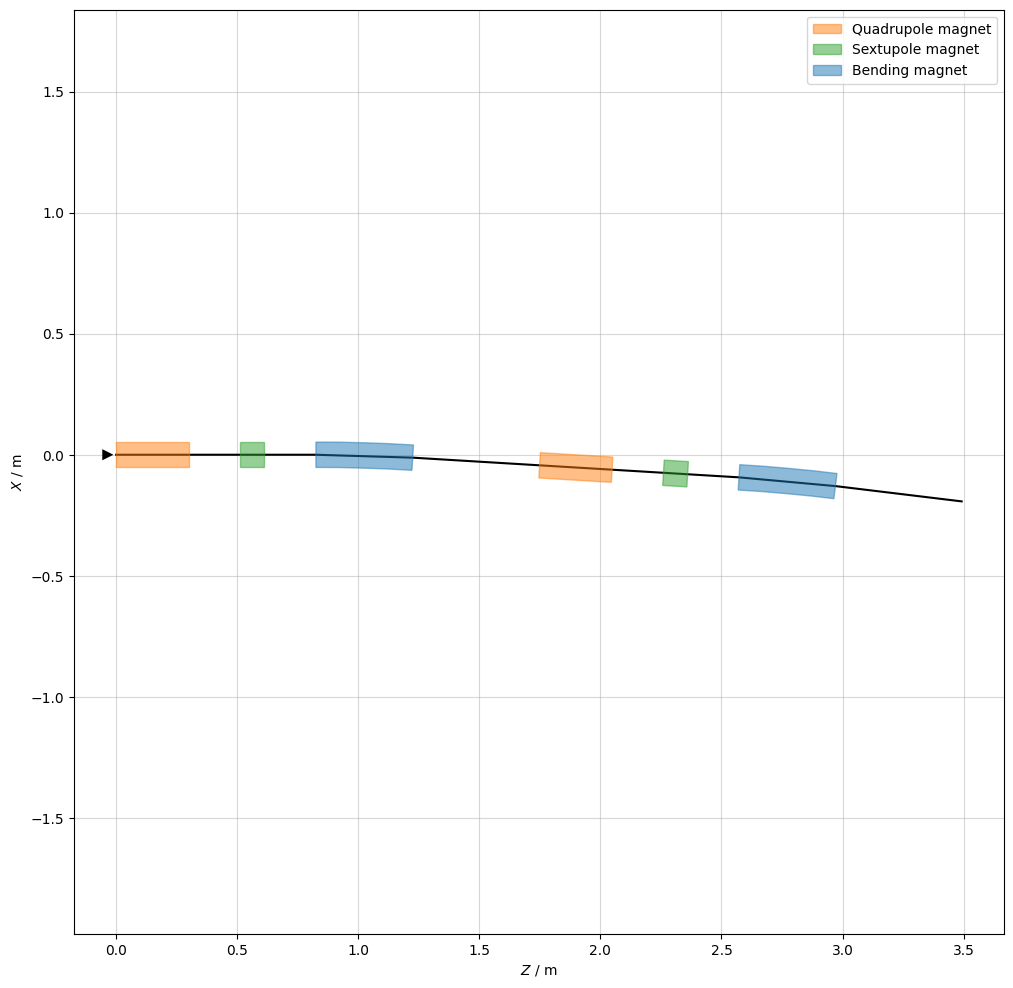

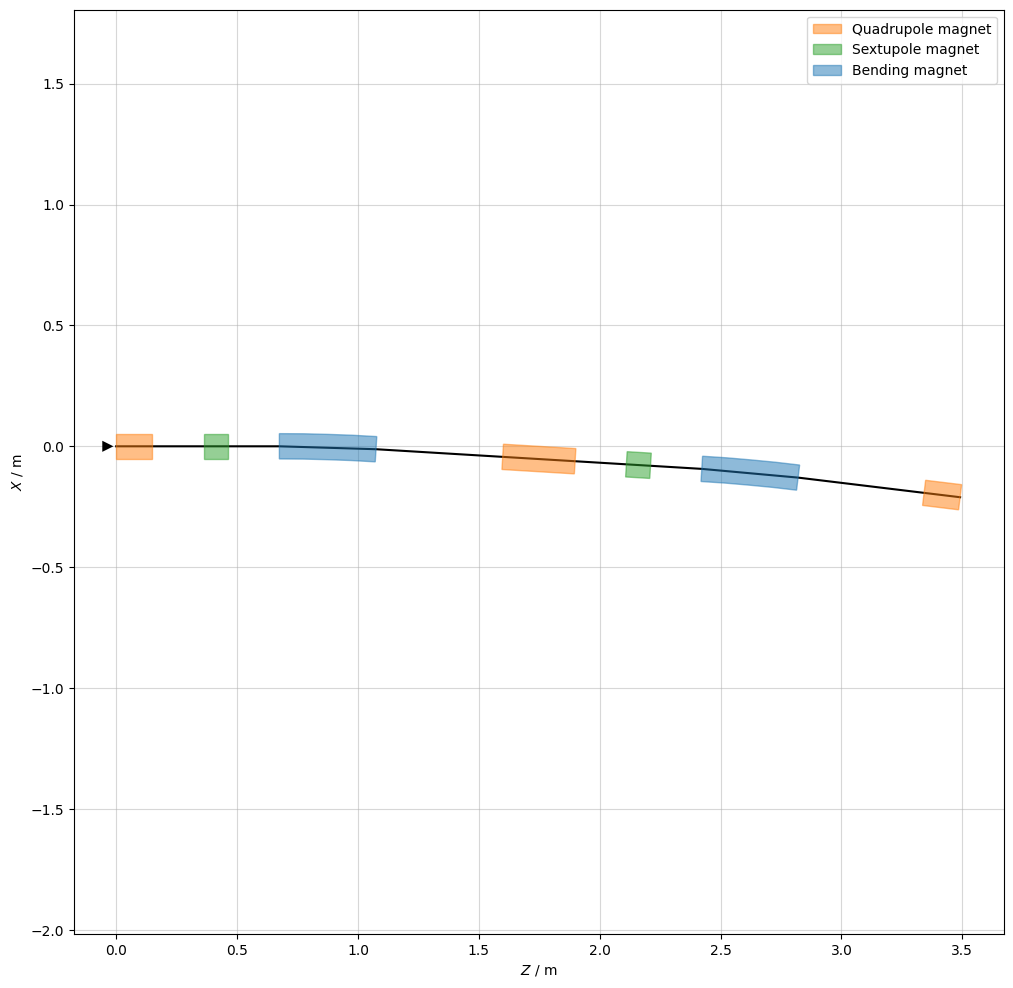

In [31]:
# just an arc cell
cell_arcS = pdr.new_line( length='l_cell', 
    components =[ 
    pdr.new('QF_cell_arc',    'QFarc',at='0*l_drift + 0.5*l_quad + 0.0*l_bend'),
    pdr.new('SF_cell_arc','SFDS', at='l_quad+(l_drift-l_sext)/2+0.5*l_sext'),
    pdr.new('Bend1_cell_arc', 'Bend', at='1*l_drift + 1.0*l_quad + 0.5*l_bend'),
    pdr.new('QD_cell_arc',    'QDarc',at='2*l_drift + 1.5*l_quad + 1.0*l_bend'),
    pdr.new('SD_cell_arc','SDDS',at='2*l_drift+2*l_quad+l_bend+l_drift/2'),
    pdr.new('Bend2_cell_arc', 'Bend', at='3*l_drift + 2.0*l_quad + 1.5*l_bend'),
    ])
cell_arcS.survey().plot()
print(cell_arcS.get_length())
cell_arc = pdr.new_line( components = [ 
   pdr.new('QF_cell_arcH1',  'QFarcH' ), pdr.place( 'Drarc2' ),
   pdr.new('SF_cell_arc1', 'SFDS'), pdr.place('Drarc2'),
   pdr.new('Bend1_cell_arcH','Bend' ),   pdr.place( 'Drarc' ),
   pdr.new('QD_cell_arcH',   'QDarc' ),  pdr.place( 'Drarc2' ),
   pdr.new('SD_cell_arc1', 'SDDS'), pdr.place('Drarc2'),
   pdr.new('Bend2_cell_arcH','Bend' ),   pdr.place( 'Drarc' ),
   pdr.new('QF_cell_arcH2',  'QFarcH' ), 
   ])
cell_arc.survey().plot()
print(cell_arc.get_length())
# triplet starting with 
cell_tr = pdr.new_line(
    components = [
    pdr.new('QF_cell_trH1', 'QFtrH',    at='0*l_trips + 0.25*l_quad + 0.0*l_tripl'),
    pdr.new('QD_cell_tr1',  'QDtr',     at='1*l_trips + 1.00*l_quad + 0.0*l_tripl'),
    pdr.new('Mkr_cell_tr',   xt.Marker, at='1*l_trips + 1.50*l_quad + 0.5*l_tripl'),
    pdr.new('QD_cell_tr2',  'QDtr',     at='1*l_trips + 2.00*l_quad + 1.0*l_tripl'),
    pdr.new('QF_cell_trH2', 'QFtrH',    at='2*l_trips + 2.75*l_quad + 1.0*l_tripl')
    ])

print(cell_tr.get_length())

In [32]:
#makesextant function
def makesextant ( name, fall ):
    comps = [ ]
    comps = comps + [pdr.new('Drarc0_'+name+str(0),'Drarc2'),pdr.new('SFA0_'+name+str(0),'SFDS')]
    for ind in range( pdr['N_cells_S'] - 1 ):  # regular arc cells
       comps = comps + [ pdr.new('Drarc1_'+ name + str(ind+1), 'Drarc2'), pdr.new('Bend1_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.new('Drarc2_'+ name + str(ind+1), 'Drarc'), pdr.new('QDA_' + name + str(ind+1), 'QDarc')]
       comps = comps + [pdr.new('Drarc3_'+name+str(ind+1),'Drarc2'),pdr.new('SDA_'+name+str(ind+1),'SDDS')]
       comps = comps + [ pdr.new('Drarc4_'+ name + str(ind+1), 'Drarc2'), pdr.new('Bend2_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.new('Drarc5_'+ name + str(ind+1), 'Drarc'), pdr.new('QFA_' + name + str(ind), 'QFarc')]
       comps = comps + [pdr.new('Drarc6_'+name+str(ind+1),'Drarc2'),pdr.new('SFA_'+name+str(ind+1),'SFDS')]
    # Replace last QF and add last arc cell (matching quads) "by hand"
    comps[-3] = pdr.new('QFAM_' + name + str(pdr['N_cells_S']), 'QFarcM' )
    comps = comps + [pdr.new('DrarcS1_'+ name + str(ind+1), 'Drarc2'),pdr.new('Bend1_' + name + str(pdr['N_cells_S']), 'Bend')]
    comps = comps + [pdr.new('Drarc7_'+ name + str(ind+1), 'Drarc'), pdr.new('QDAM_' + name + str(pdr['N_cells_S']), 'QDarcM')]
    comps = comps + [pdr.new('Drarc75_'+name+str(ind+1),'Drarc2'),pdr.new('SDAM_'+name+str(ind+1),'SDDS')]
    comps = comps + [pdr.new('Drarc8_'+ name + str(ind+1), 'Drarc2'), pdr.new('Bend2_' + name + str(pdr['N_cells_S']), 'Bend')]
    # Add dispersion suppressor
    comps = comps + [pdr.new('Drarc9_'+ name + str(ind+1), 'Drarc'), pdr.new('QFDS_' + name, 'QFDS') ]
    comps = comps + [pdr.new('DrDSL1_'+ name + str(ind+1), 'DrDSL'), pdr.new('QDDS_' + name, 'QDDS') ]
    comps = comps + [pdr.new('Drarc10_'+ name + str(ind+1), 'Drarc'), pdr.new('BendDS_' + name, 'BendDS')]
    # Add doublet matching 
    comps = comps + [pdr.new('DrTrans1_'+ name + str(ind+1), 'DrTrans'), pdr.new('QFDoub_' + name, 'QFDoub')]
    comps = comps + [pdr.new('DrDoub1_'+ name + str(ind+1), 'DrDoub'), pdr.new('QDDoub_' + name, 'QDDoub')]   
    comps = comps + [pdr.new('DrTripl1_'+ name + str(ind+1), 'DrTripl'), pdr.new('QDTrip_' + name + '1', 'QDtr')]  
    if fall == 'symm':
       comps = [ pdr.new('QFA_' + name + 'CH', 'QFarcH' ) ] + comps
       comps = comps + [ pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2H', 'QFtrH')]
    elif fall == 'right':
       comps = [ pdr.new('QFA_' + name + 'C', 'QFarc'  ) ] + comps + [ pdr.place('DrTrips') ]
    elif fall == 'left':
       comps = comps + [pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2', 'QFtr') ]
       comps = list( reversed(comps) )
    else:
       print( '=====> choice for sextant version incorrect <=====' )
       quit()
    return pdr.new_line( components = comps )

Slicing line:   0%|          | 0/109 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/109 [00:00<?, ?it/s]

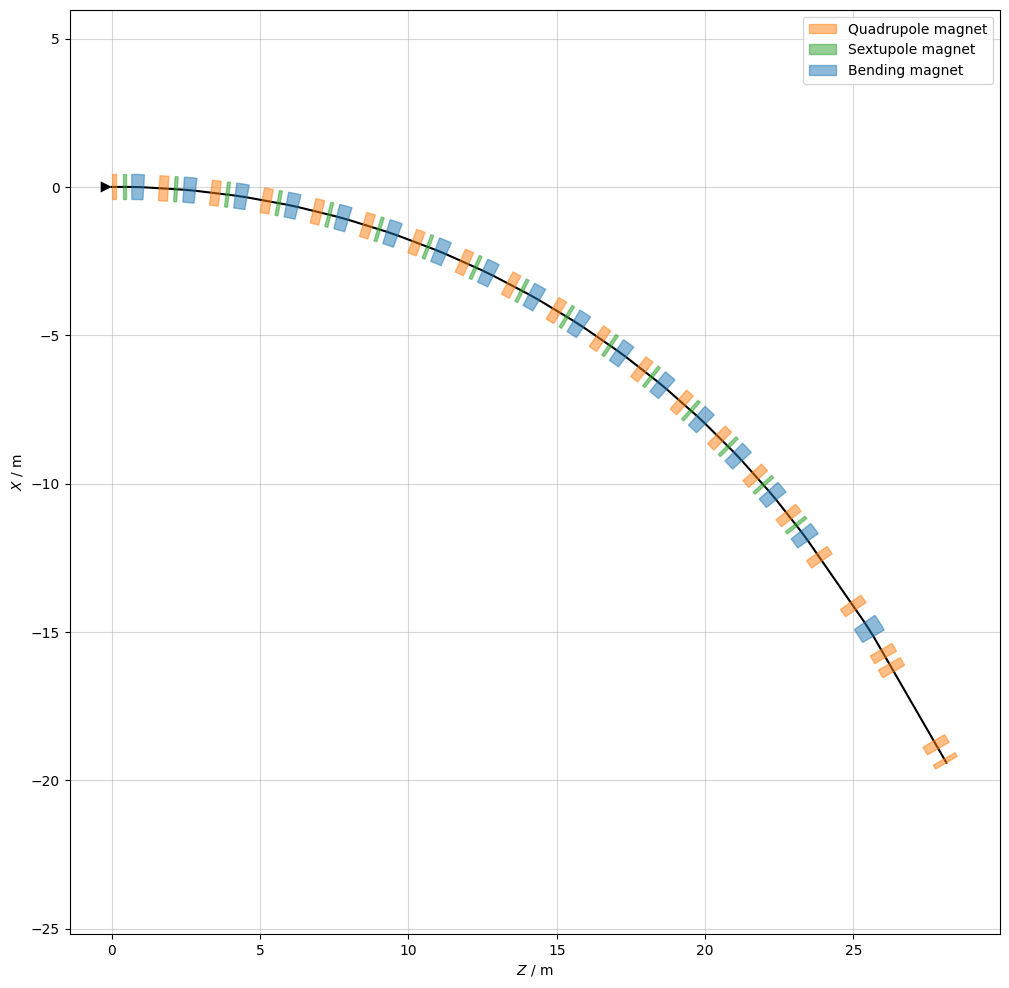

In [33]:
arc1R = makesextant( 'xR', 'symm' )
arc1R_sliced = arc1R.select()
arc1R_sliced.cut_at_s( np.linspace(.05, arc1R.get_length()-.05, int(arc1R.get_length()/.05-.5)) )
arc1R.insert( pdr.new('CtrS1_xR1', xt.Marker ), at='(l_tripl+l_quad)/2', from_='QDDoub_xR' )
arc1R.survey().plot()

In [34]:
# %% Routine for several matchings in a row for 90 degrees arc cells and given tunes

# Matching of arc cell
cell_arc_opt = cell_arc.match( method='4d', solve=True, verbose=False,
    vary=[
        xt.VaryList(['kQFarc', 'kQDarc', 'kQFarcM'], step=1e-4),    ],
    targets=[
        xt.TargetSet(qx=0.25, qy=0.25, tol=1.0e-6, tag='end'), # just twice the same 
        xt.TargetSet(mux=0.25, muy=0.25, at=xt.END, tol=1.0e-6)]  )

# Triplet cell to chosen betatron functions
cell_tr_opt = cell_tr.match( method='4d', solve=True,
    vary=[ # use individual Vary commands instead of List for arc cell
        xt.Vary('kQFtr', step=1e-4 ),
        xt.Vary('kQDtr', step=1e-4),    ],
    targets=[
        xt.TargetSet(betx=2.50, bety=2.50, at='Mkr_cell_tr', tol=1.0e-6, tag='betas')] )


# Matching sequence with ring working as (one of the) target(s)
def matchingWP( qx, qy, MakePlot=False ):
    cell_arc_opt.run_jacobian(10)
    cell_arc_tw = cell_arc.twiss( method='4d' )
    arc1R_opttune = arc1R.match( method='4d', solve=True, verbose=False,
                 betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                 bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                 dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],
            vary=[ xt.VaryList(['kQFarcM', 'kQDarcM'], step=1e-4),
                   xt.VaryList(['kQFDS', 'kQDDS'], step=1e-4),
                   xt.VaryList(['kQFDoub', 'kQDDoub'], step=1e-4),
                   xt.VaryList(['kQFtr', 'kQDtr'], step=1e-4), ],
            targets=[ xt.TargetSet(dx=0, dpx=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(mux=qx/6, muy=qy/6, at=xt.END, 
                                   tol=1.0e-9, weight=.1, tag='phase'),
                      xt.TargetSet(alfx=0, alfy=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(alfx=0, alfy=0, at='CtrS1_xR1', 
                                   tol=1.0e-9, weight=10.) ])
    arc1R_opttune.run_jacobian(50)
    if MakePlot:
       arc1R.twiss( method='4d',
                    betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                    bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                    dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],).plot() 
        
# Matching sequence for sextant with beta at center of straights fixed
def matchingBeta( betxS, betyS, MakePlot=False ): #, **kwargs ):
    cell_arc_opt.run_jacobian(10)
    cell_arc_tw = cell_arc.twiss( method='4d' )
    cell_tr_opt.targets[0].value, cell_tr_opt.targets[1].value = betxS, betyS
    cell_tr_opt.run_jacobian(10)
    cell_tr_tw = cell_tr.twiss( method='4d' )
    arc1R_opt = arc1R.match( method='4d', solve=True,
                 betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                 bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                 dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],
            vary=[ xt.VaryList(['kQFarcM', 'kQDarcM'], step=1e-4),
                   xt.VaryList(['kQFDS', 'kQDDS'], step=1e-4),
                   xt.VaryList(['kQFDoub', 'kQDDoub'], step=1e-4) ],
            targets=[ xt.TargetSet(dx=0, dpx=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(alfx=0, alfy=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(betx=cell_tr_tw.betx[0], bety=cell_tr_tw.bety[0],
                                   at=xt.END, tol=1.0e-9) ])
    arc1R_opt.run_jacobian(10)
    if MakePlot:
       arc1R.twiss( method='4d',
                    betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                    bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                    dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],).plot() 
       


cell_tr_tw = cell_tr.twiss(method='4d')
mid_idx = len(cell_tr_tw.betx) // 2
betxS = cell_tr_tw.betx[mid_idx]
betyS = cell_tr_tw.bety[mid_idx]
matchingBeta( betxS, betyS, MakePlot=False )

#matchingWP(14.88987,14.68614)
#matchingWP(15.101,15.353)


                                             07              
Optimize - start penalty: 0.8598                            
Matching: model call n. 21 penalty = 4.8109e-09              
Optimize - end penalty:  4.81094e-09                            
                                             07              
Optimize - start penalty: 0                                  
Matching: model call n. 23 penalty = 0.0000e+00              
Optimize - end penalty:     0                            
                                             
Optimize - start penalty: 6.891                             
Matching: model call n. 188 penalty = 4.4630e-10              
Optimize - end penalty:  4.463e-10                            
                                             
Optimize - start penalty: 4.463e-10                           
Matching: model call n. 190 penalty = 4.4630e-10              
Optimize - end penalty:  4.463e-10                            


In [35]:
def addSketchBL(acc_tw, acc, lims, limy1, limy2, scK1):
    # Added a 4th row for Chromatic Functions (axw)
    fig, ax = plt.subplots(4, 1, figsize=(12, 12), 
                           height_ratios=(1, 3, 2, 2))
    axl, axp, axw, axt = ax  # Lattice, Optics, W-functions, Text Table
    
    # Link the x-axes so zooming on one zooms all
    axp.sharex(axl)
    axw.sharex(axl)
    fig.subplots_adjust(hspace=0.1, top=0.95, bottom=0.05, left=.1)

    # --- Subplot 2: Beta and Dispersion ---
    axp.set_ylabel(r'$\beta_x, \beta_y$ [m]')
    indm = np.argmin(np.abs(acc_tw.s - lims[-1])) + 1
    
    axp.plot(acc_tw.s[:indm], acc_tw.betx[:indm], color='red', label=r'$\beta_x$')
    axp.plot(acc_tw.s[:indm], acc_tw.bety[:indm], color='blue', label=r'$\beta_y$')
    axp.set_ylim(limy1)
    
    axp2 = axp.twinx()
    axp2.plot(acc_tw.s[:indm], acc_tw.dx[:indm], color='black', linestyle='--', label='$D_x$')
    axp2.set_ylabel(r'$D_x$ [m]')
    axp2.set_ylim(limy2)
    axp.set_xlim(lims)

    # --- Subplot 3: Chromatic W Functions ---
    axw.plot(acc_tw.s[:indm], acc_tw.wx_chrom[:indm], label='$W_x$', color='darkblue')
    axw.plot(acc_tw.s[:indm], acc_tw.wy_chrom[:indm], label='$W_y$', color='darkred')
    

    '''tt_sliced = acc.get_table(attr=True)
    tbends = tt_sliced.rows[tt_sliced.element_type == 'Bend']
    
    # Apply shading ONLY to the Chromatic W-functions axis
    for nn in tbends.name:
        axw.axvspan(
            tbends['s', nn], 
            tbends['s', nn] + tbends['length', nn],
            color='tab:blue', 
            alpha=0.15,       # Subtle enough to see the Wx/Wy lines
            linewidth=0
        )'''
    
    axw.set_ylabel('Chromatic $W$')
    axw.set_xlabel('Position s [m]')
    axw.legend(loc='upper right', fontsize=8)
    axw.grid(True, alpha=0.3)
    # --- Subplot 1: Lattice Sketch ---
    axl.set_ylim(-0.5, 1.5)
    axl.axis('off')
    tab_pan = acc.get_table(attr=True).to_pandas()
    for ind in range( len(tab_pan.T.columns) -1 ):
        if tab_pan['element_type'][ind].find('Drift') >= 0:
           axl.plot( [tab_pan['s'][ind], tab_pan['s'][ind+1]], [0, 0], color='black' )
        if tab_pan['element_type'][ind].find('Bend') >= 0:
           axl.add_patch( patches.Rectangle( (tab_pan['s'][ind], -0.08), 
               tab_pan['s'][ind+1] - tab_pan['s'][ind], 0.16, fill=True, color='tab:blue' ) ) 
        if tab_pan['element_type'][ind].find('Quad') >= 0:
           kstr = scK1*tab_pan['k1l'][ind]/tab_pan['length'][ind]
           axl.add_patch( patches.Rectangle( (tab_pan['s'][ind], min(0.0, kstr)),
               tab_pan['s'][ind+1] - tab_pan['s'][ind], abs(kstr), fill=True, color='tab:orange' ) )   
        if tab_pan['element_type'][ind].find('Sext') >= 0:
           kstr = scK1*tab_pan['k2l'][ind]/tab_pan['length'][ind]*0.05
           axl.add_patch( patches.Rectangle( (tab_pan['s'][ind], min(0.0, kstr)) ,
               tab_pan['s'][ind+1] - tab_pan['s'][ind], abs(kstr), fill=True, color='tab:green' ) )     
    axp.plot( [acc.get_length(), acc.get_length()], limy1, color='black', 
              linestyle=(0, (8, 8)), linewidth=.5 )

    # --- Subplot 4: Text Area ---
    axt.axis('off')
    axt.set_xlim(-0.3, 4.0)
    axt.set_ylim(0, 1.5)

    return axt
    
    

# Routine generating graphical and text output describing the ring    
def SpuckParsAus( acc_tw, acc, lims, limy1, limy2, scK1, grname='NoGraph' ):
    axt = addSketchBL( acc_tw, acc, lims, limy1, limy2, scK1 )
    axt.text( 0.0, .7, f'C ={3*acc_tw.circumference:8.4f} m', horizontalalignment='left' )
    axt.text( 1.0, .7, f'T ={3e6*acc_tw.T_rev0:8.4f} us', horizontalalignment='left')
    axt.text( 2.0, .7, r'($Q_x$, $Q_y$)' + f' = ({3*acc_tw.qx:9.5f}, {3*acc_tw.qy:9.5f})',horizontalalignment='left')
    
    pos=0
    for item in pdr.vars.keys()[2:]:
       print( "'" + item + f"': {pdr[item]:8.4f}," )
       axt.text( pos%4 , .6 - .1*int( pos/4 ),
          "'" + item + f"': {pdr[item]:8.4f},", horizontalalignment='left' )
       pos += 1
    file=os.getcwd()
    if grname != 'NoGraph': 
       if grname in file:
          print( ' Error: file ' + grname + ' exists <<<<<<<<<<<================' )
       else:
          plt.savefig( file + grname )
    tab_pan = acc.get_table(attr=True).to_pandas()
    print('  Name        Type      L(m)     sin(m)   sout(m)  driftl  driftr    k1(1/m^2)')
    for ind in range( len(tab_pan.T.columns) - 1 ):
       eltyp = tab_pan['element_type'][ind]
       if eltyp.find('Drift') < 0:
          elnam = tab_pan['name'][ind]
          if ind < 1: sin = '  0.0000'
          else: sin = f"{tab_pan['length'][ind-1]:8.4f}"         
          k1expr = pdr.element_refs[elnam].k1._expr
          if k1expr == None: k1expr = ' None'
          else: k1expr = str(k1expr)[5:-1]
          print(  "  " + elnam.ljust( 12 ) + eltyp.ljust(12)[:8] + f" {tab_pan['length'][ind]:7.4f} " + 
               f"{tab_pan['s'][ind]:8.4f} {tab_pan['s'][ind+1]:8.4f} " + sin +
               f"{tab_pan['length'][ind+1]:8.4f} " + k1expr.ljust(9) + 
               f"= {tab_pan['k1l'][ind]/max(tab_pan['length'][ind],1e-6):7.4f}  " )

Slicing line:   0%|          | 0/218 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/648 [00:00<?, ?it/s]

Targeting element: QFA_2RC
Target status:               nalty = 3.0552e-06              
id state tag tol_met       residue   current_val target_val description                       
0  ON    dqx    True  -3.05521e-06  -3.05521e-06          0 'dqx', val=0, tol=0.0001, weight=1
1  ON    dqy    True   1.42139e-09   1.42139e-09          0 'dqy', val=0, tol=0.0001, weight=1
Target status:               nalty = 3.0552e-06              
id state tag tol_met       residue   current_val target_val description                       
0  ON    dqx    True  -3.05521e-06  -3.05521e-06          0 'dqx', val=0, tol=0.0001, weight=1
1  ON    dqy    True   1.42139e-09   1.42139e-09          0 'dqy', val=0, tol=0.0001, weight=1
Matched kSF: 74.790064
Matched kSD: -106.848204
+-------------------------------------+---------------------+-------+
| Parameter                           |               Value |  Unit |
+-------------------------------------+---------------------+-------+
| Horizontal Chromati

"ax.plot(ring_tw.s, ring_tw.wx_chrom, label=r'$W_x$')\nax.plot(ring_tw.s, ring_tw.wy_chrom, label=r'$W_y$')\n\nax.set_xlabel('Position s [m]')\nax.set_ylabel('W-function')\nax.set_title('Chromatic Functions')\nax.legend()\nax.grid(True)\n\nplt.show()"

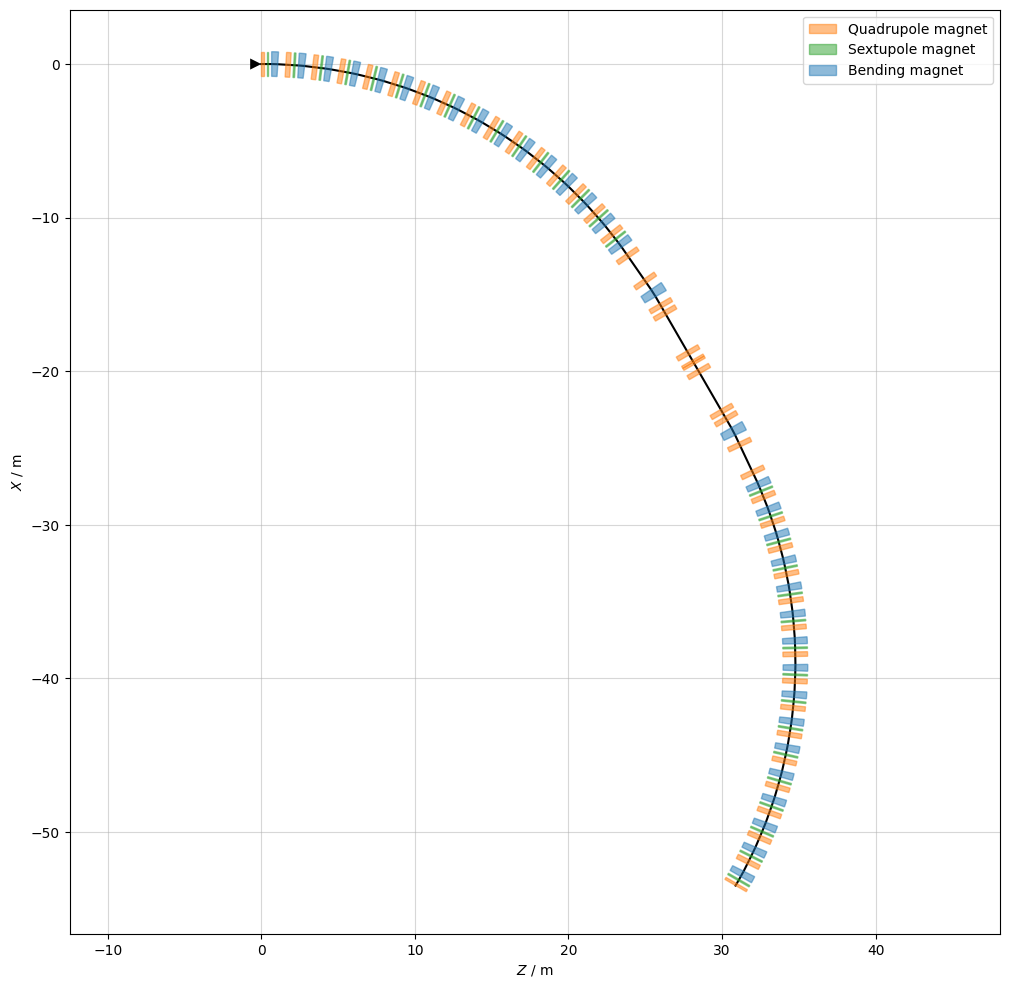

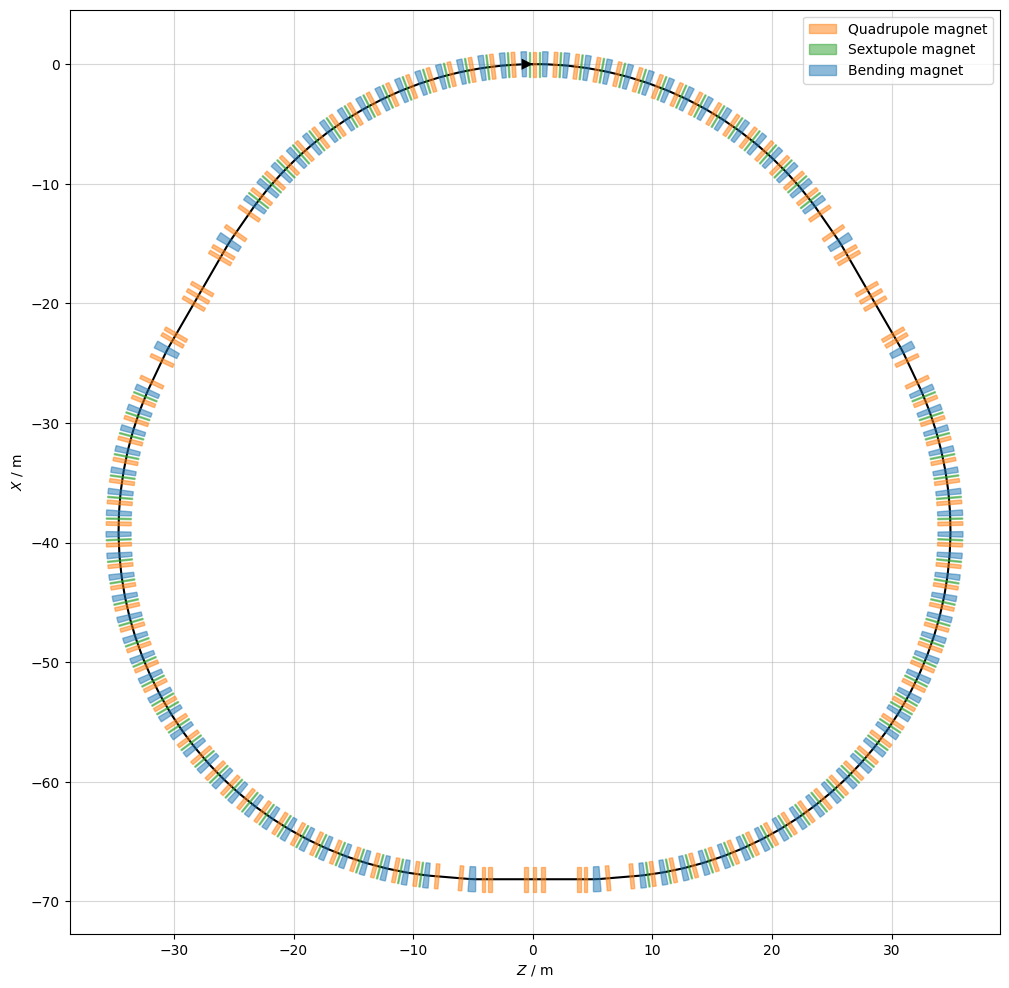

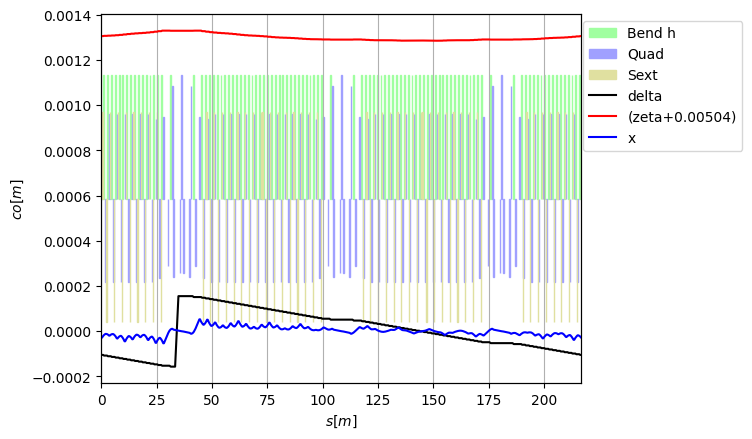

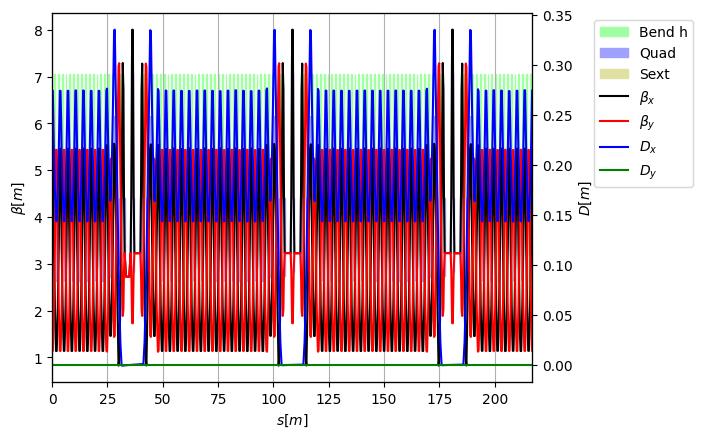

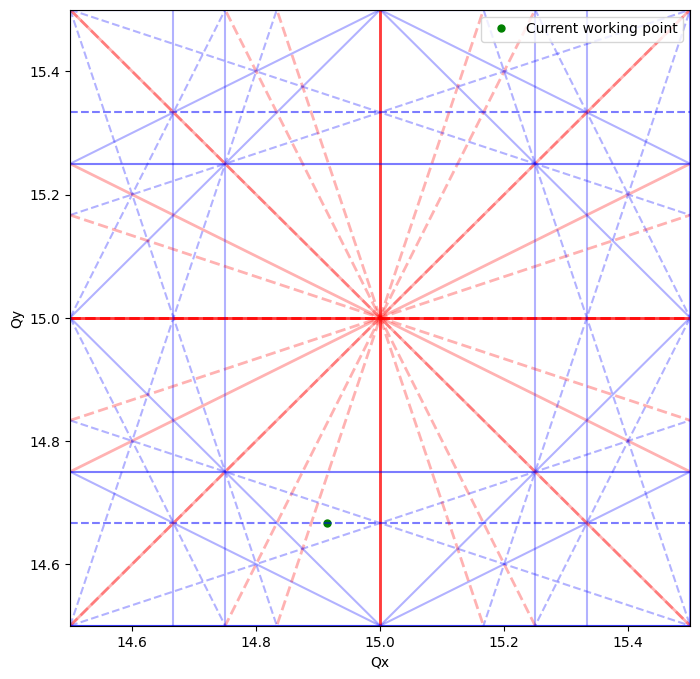

In [36]:
# One period from center of arc to center of arc
plt.rcParams['figure.figsize'] = [12,12]
period = makesextant( 'PR', 'symm') + ( -makesextant( 'PL', 'symm') )
period.survey().plot()
period_sliced = period.select()
period_sliced.cut_at_s( np.linspace(.05, period.get_length()-.05, int(period.get_length()/.05-.5)) )

# Full ring without X-poles, RF and wigglers
ring  = makesextant( '1R', 'right') + makesextant( '2L', 'left') + makesextant( '2R', 'right') + makesextant( '3L', 'left') + makesextant( '3R', 'right') + makesextant( '1L', 'left')



#useful_functions.ChromCorrect(ring,'kSF', 'kSD')
#useful_functions.SpuckParsAus( period_sliced.twiss(method='4d'), period,(0., 38.), (0., 10.), (0., 1.), .08, "Standard.pdf" )



fRev = 1./(ring.twiss(method='4d').T_rev0)
fRF  = fRev*round(4.e8/fRev)  # at integer harmonics and close to 400 MHz
pdr.new('RFCav',  xt.Cavity, length=1.5, frequency=fRF, voltage=VRF, 
        lag=(180/np.pi)*(np.pi - np.arcsin(U0/VRF)) - 1.8 ) 
ring.insert( pdr.new('RFCav_1', 'RFCav'), at='(l_tripl+l_quad)/2', from_='QDDoub_1R' )
ring.configure_radiation(model='mean')
ring.configure_bend_model(edge='full')
ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True,
                   spin=True, polarization=True )


ring.survey().plot()
plt.savefig('ring_survey_1.png')


ring_tw.plot('delta (zeta+0.00504) x')
plt.savefig('ring_twiss_1.png')

ring_tw.plot()
plt.savefig('ring_delta_1.png')

def ChromCorrect(ksf, ksd, MakePlot=False):
        
    opt_chrom = ring.match(
        solve=True,
        verbose=False,
        method='6d',
        vary=xt.VaryList([ksf, ksd], step=1e-3),
        targets=[
            # Global goals
            xt.Target(dqx=0, tol=1e-4),
            xt.Target(dqy=0, tol=1e-4),
            
            
        ])
    opt_chrom.target_status()
    opt_chrom.run_jacobian(n_steps=100)
    opt_chrom.target_status()
    # Print the final matched strengths

    print(f"Matched kSF: {pdr.vars['kSF']._get_value():.6f}")
    print(f"Matched kSD: {pdr.vars['kSD']._get_value():.6f}")   

'''def ChromCorrectLocal(ring, ksf_name, ksd_name, period_end_name):
    opt = ring.match(
        solve=True,
        method='6d',
        vary=[
            xt.Vary(ksf_name, step=1e-4),
            xt.Vary(ksd_name, step=1e-4),
            # Suggestion: Add two more families if the match struggles!
        ],
        targets=[
            # Global goals
            xt.Target(dqx=0, tol=1e-4),
            xt.Target(dqy=0, tol=1e-4),
            
            # Local goals at the end of the 3-fold period
            xt.Target(wx_chrom=0,  at=period_end_name, tol=1e-3),
            xt.Target(wy_chrom=0,  at=period_end_name, tol=1e-3),
        ]
    )
    return opt'''
# Find the name of the element at the end of the first period
tab = ring.get_table()

period_length = ring_tw.circumference / 3.0
# Find element closest to the 1/3 mark
period_end_name = tab.name[np.argmin(np.abs(tab.s - period_length))]

print(f"Targeting element: {period_end_name}")

ChromCorrect('kSF', 'kSD', MakePlot=False)

# Initialize the table
t = PrettyTable()
t.field_names = ["Parameter", "Value", "Unit"]
t.align["Parameter"] = "l"
t.align["Value"] = "r"

# Parameters
t.add_row([f"Horizontal Chromaticity (dqx)",f"{ring_tw.dqx:.4f}",''])
t.add_row([f"Vertical Chromaticity (dqy)",   f"{ring_tw.dqy:.4f}",''])
t.add_row([f"Max Betx", f"{max(ring_tw.betx):.2f}" ,"m"])
t.add_row([f"Max Bety", f"{max(ring_tw.bety):.2f}" ,"m"])
t.add_row(["Harmonic Number", f"{fRF/fRev:10.5f}", ""])
t.add_row(["RF Frequency", f"{fRF:8.5f}", "MHz"])
t.add_row(["Length of short drifts", f"{pdr['l_drift']:7.3f}", "m"])
t.add_row(["Circumference", f"{ring_tw.circumference:8.4f}", "m"])
t.add_row(["Revolution Time", f"{1e6*ring_tw.T_rev0:8.5f}", "us"])
t.add_row(["Energy Loss (Manual)", f"{U0:10.2f}", "keV"])
t.add_row(["Energy Loss (Twiss)", f"{ring_tw.eneloss_turn:10.2f}", "keV"])
t.add_row(["Vertical Damping Time", f"{1/ring_tw.damping_constants_turns[1]:10.3f}", "turns"])
t.add_row(["Horizontal Tune (qx)", f"{ring_tw.qx:10.5f}", ""])
t.add_row(["Vertical Tune (qy)", f"{ring_tw.qy:10.5f}", ""])
t.add_row(["Equilibrium Polarization", f"{ring_tw.spin_polarization_eq:8.5f}", ""])
t.add_row(["Polarization Build-up Time", f"{ring_tw.spin_t_pol_buildup_s:10.2f}", "s"])
t.add_row(["Horizontal Damping time constant ", f' {ring_tw.damping_constants_s[0]}',"s"])
t.add_row(["Vertical Damping time constant ", f'{ring_tw.damping_constants_s[1]}',"s"])
t.add_row(["Longitudinal Damping time constant ", f'{ring_tw.damping_constants_s[1]}',"s"])
print(t)

#print(ring_tw.keys())

#Working point plot
resonance_orders = (1,2,3,4)
Qx_range = (14.5, 15.5)
Qy_range = (14.5, 15.5)
resonances = resonance_lines(Qx_range,Qy_range,resonance_orders,3)
fig, ax = plt.subplots(1, figsize=(8,8), alpha=0.3)
ax.plot(ring_tw.qx, ring_tw.qy,'o', 
                color='green', label='Current working point', markersize=5)
ax.legend()
resonances.plot_resonance(fig)
plt.savefig('working_point_1.png')

#Chromatic functions
# Plot Wx and Wy
'''ax.plot(ring_tw.s, ring_tw.wx_chrom, label=r'$W_x$')
ax.plot(ring_tw.s, ring_tw.wy_chrom, label=r'$W_y$')

ax.set_xlabel('Position s [m]')
ax.set_ylabel('W-function')
ax.set_title('Chromatic Functions')
ax.legend()
ax.grid(True)

plt.show()'''

'l_cell':   3.5000,
'l_bend':   0.4000,
'l_bendDS':   0.5500,
'dl_noben':   0.2500,
'l_quad':   0.3000,
'l_drift':   0.5250,
'dl_drift':  -0.1500,
'dl_trans':   0.0000,
'l_doub':   0.2500,
'l_tripl':   2.7000,
'l_trips':   0.4000,
'N_cells_S':   8.0000,
'hBarc':   0.1507,
'kQFarc':   2.8579,
'kQDarc':  -2.8333,
'kQFarcM':   2.7027,
'kQDarcM':  -2.6748,
'kQFDS':   2.7587,
'kQDDS':  -2.2909,
'kQFDoub':   3.8148,
'kQDDoub':  -2.6690,
'kQFtr':   4.1709,
'kQDtr':  -2.5250,
'l_sext':   0.1000,
'kSF':  74.7901,
'kSD': -106.8482,
  Name        Type      L(m)     sin(m)   sout(m)  driftl  driftr    k1(1/m^2)
  QFA_PRCH    Quadrupo  0.1500   0.0000   0.1500   0.0000  0.2125 'kQFarc' =  2.8579  
  SFA0_PR0    Sextupol  0.1000   0.3625   0.4625   0.2125  0.2125  None    =  0.0000  
  Bend1_PR1   Bend      0.4000   0.6750   1.0750   0.2125  0.5250  None    =  0.0000  
  QDA_PR1     Quadrupo  0.3000   1.6000   1.9000   0.5250  0.2125 'kQDarc' = -2.8333  
  SDA_PR1     Sextupol  0.1000   2.1125   2.2

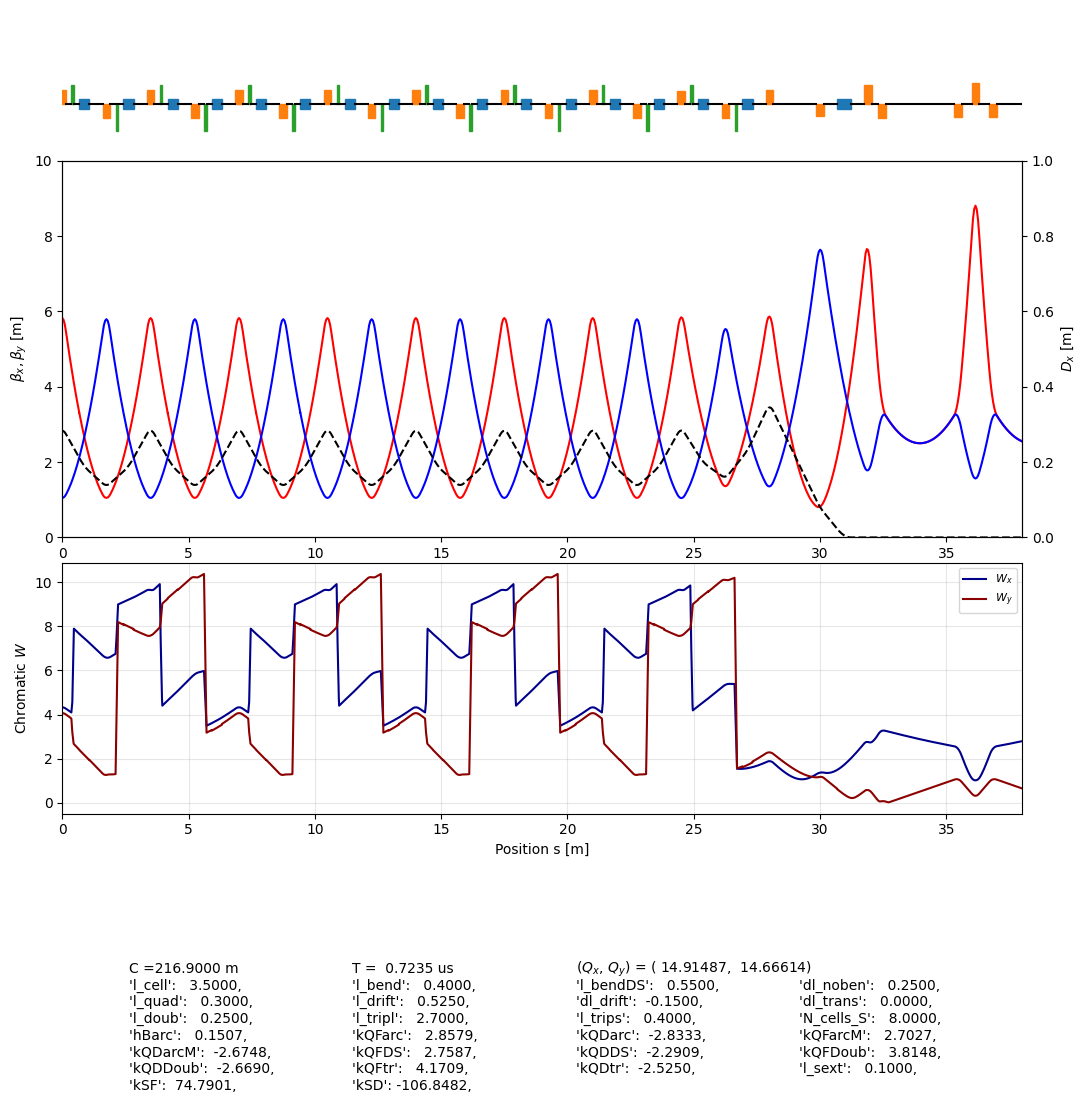

In [37]:
SpuckParsAus( period_sliced.twiss(method='4d'), period,(0., 38.), (0., 10.), (0., 1.), .08, "Standard.png" )

ValueError: Invalid n1

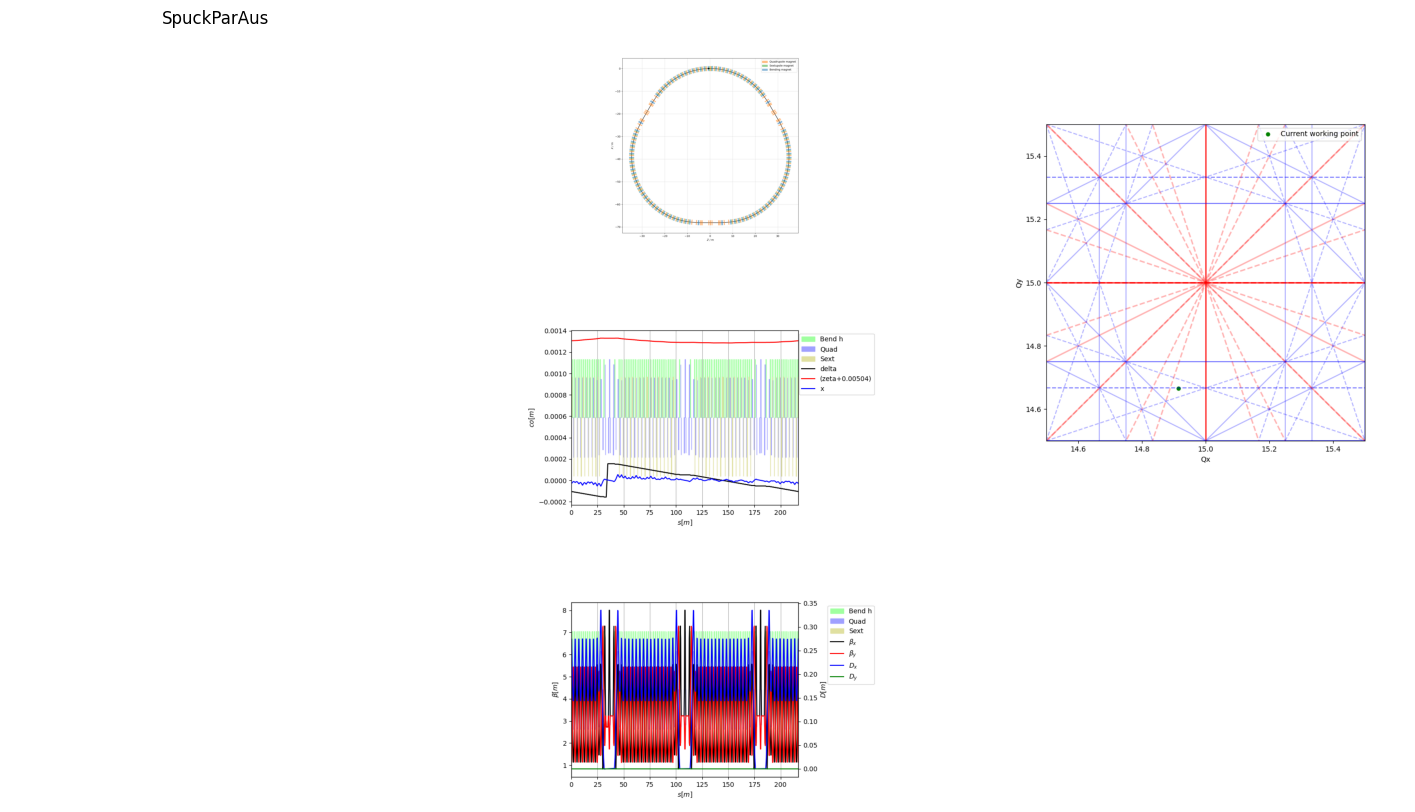

In [41]:
import io
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec



def make_info_sheet_io():

    fig = plt.figure(figsize=(18, 10))
    gs = GridSpec(3, 3, figure=fig)

    # Convert existing figures to images
    #img_spuck  = mpimg.imread("NotebooksStandard.png")
    img_twiss  = mpimg.imread("ring_twiss_1.png")
    img_survey = mpimg.imread("ring_survey_1.png")
    img_delta  = mpimg.imread("ring_delta_1.png")
    img_wp     = mpimg.imread("working_point_1.png")

    # --- LEFT COLUMN ---
    ax_spuck = fig.add_subplot(gs[:, 0])
    #ax_spuck.imshow(img_spuck)
    ax_spuck.axis('off')
    ax_spuck.set_title("SpuckParAus")

    # --- MIDDLE COLUMN ---
    ax_survey = fig.add_subplot(gs[0, 1])
    ax_survey.imshow(img_survey)
    ax_survey.axis('off')

    ax_twiss = fig.add_subplot(gs[1, 1])
    ax_twiss.imshow(img_twiss)
    ax_twiss.axis('off')

    ax_delta = fig.add_subplot(gs[2, 1])
    ax_delta.imshow(img_delta)
    ax_delta.axis('off')

    # --- RIGHT COLUMN ---
    ax_wp = fig.add_subplot(gs[0:2, 2])
    ax_wp.imshow(img_wp)
    ax_wp.axis('off')

    # Parameter table (still native)
    ax_table = fig.add_subplot(gs[2, 2])
    ax_table.axis('off')

    tw = arc1R.twiss(method='4d')
    table_data = [
        ["Qx", f"{tw.qx:.3f}"],
        ["Qy", f"{tw.qy:.3f}"],
    ]

    ax_table.table(cellText=table_data,
                   colLabels=["Parameter", "Value"],
                   loc='center')

    plt.tight_layout()
    plt.show()

make_info_sheet_io()

 Energy loss per turn from twiss  892439.32 and me  891804.40
[6588.49302863 6410.54153809 3162.44749082]
6409.3993308213485
At reference location: D = 0.2743 m, Dp = 0.1201, betx = 5.4626 m, alfx =-2.3653, betl =14.6807 m 


Tracking: 100%|██████████| 6100/6100 [04:10<00:00, 24.36it/s]


 ==> Plotting turn"    1
 ==> Plotting turn" 2000
 ==> Plotting turn" 4000
 ==> Plotting turn" 6000
[151.71892438360496, 2000000.0]
 Particle survival:   200 out of   200


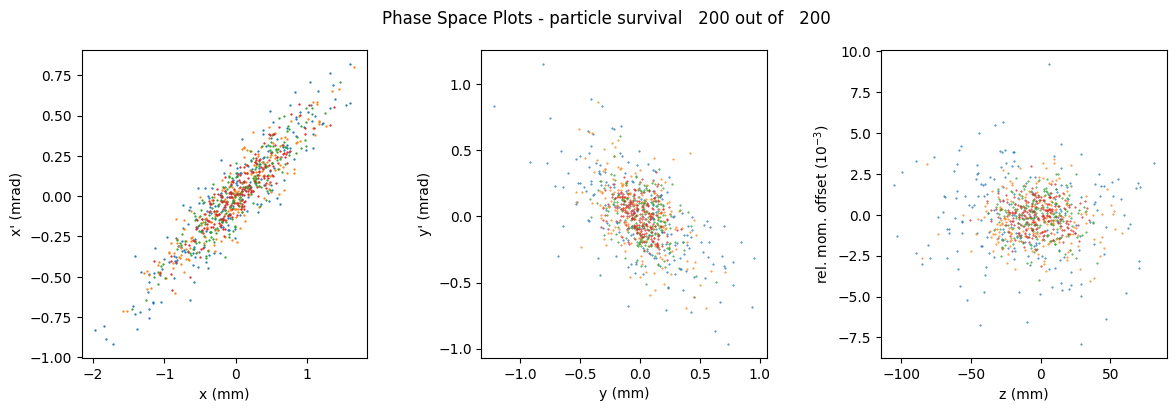

In [ ]:
# %% Simple test of tracking with synchrotron radiation - takes some time
ring.configure_radiation(model='mean')
ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True)
#ring_tw.plot()
#print( ring_tw.keys() )
print( f' Energy loss per turn from twiss {ring_tw.eneloss_turn:10.2f} and me {U0:10.2f}')
print( 1/ring_tw.damping_constants_turns )
print( 2*E0/ring_tw.eneloss_turn )

npts = 200
epsx, epsy, epsl = 1.0e-7, 1.0e-7, 1.0e-4  # starting with somewhat large emittances
betxin, alfxin  = ring_tw.betx[0], ring_tw.alfx[0] 
xin, pxin       = ring_tw.x[0], ring_tw.px[0]
dxin, dpxin     = ring_tw.dx[0], ring_tw.dpx[0]
betyin, alfyin  = ring_tw.bety[0], ring_tw.alfy[0] 
yin, pyin       = ring_tw.y[0], ring_tw.py[0]   # should be zero for perfect case
#epsx, epsl      = 2.0*ring_tw.eq_gemitt_x, 2.0*ring_tw.eq_gemitt_zeta
betlin          = ring_tw.bets0
zetain, deltain = ring_tw.zeta[0], ring_tw.delta[0]
print( f'At reference location: D ={dxin:7.4f} m, Dp ={dpxin:7.4f},' +
       f' betx ={betxin:7.4f} m, alfx ={alfxin:7.4f},' + 
       f' betl ={betlin:7.4f} m ')

normat = np.array([
    [(epsx*betxin)**.5,         0,                 0,  0, 0, dxin*(epsl/betlin)**.5],
    [-alfxin*(epsx/betxin)**.5, (epsx/betxin)**.5, 0,  0, 0, dpxin*(epsl/betlin)**.5],
    [0,  0,  (epsx*betyin)**.5,         0,                 0, 0],
    [0,  0,  -alfyin*(epsx/betyin)**.5, (epsx/betyin)**.5, 0, 0],
    [0, 0, 0, 0, (epsl*betlin)**.5, 0                ],
    [0, 0, 0, 0, 0,                 (epsl/betlin)**.5]               
    ])

parts = np.array([
     [xin, pxin, yin, pyin, zetain, deltain] + normat@np.random.randn(6) 
         for ind in range(npts) ]).T
# quit()
p2 = xt.Particles(kinetic_energy0 = 2860.e6, mass0 = xt.ELECTRON_MASS_EV,
                  x    = parts[0], px   = parts[1],
                  y    = parts[2], py   = parts[3],
                  zeta = parts[4], delta = parts[5] )
ring.configure_radiation(model='quantum')
ring.track( p2, num_turns = 6100, turn_by_turn_monitor = True,
            with_progress = True )

data = ring.record_last_track
trnplt = [1, 2000, 4000, 6000]
#trnplt = range( len(data.x.T) ) # superimpose all turns, rendering is slowish
fig = plt.figure( figsize=(14., 4.) )
fig.suptitle( f'Phase Space Plots - particle survival {int(((p2.state + 1)/2).sum()):5d} out of {npts:5d}' )
ax = fig.subplots(1, 3)
fig.subplots_adjust( wspace=0.4 )
ax[0].set_xlabel('x (mm)')
ax[0].set_ylabel("x' (mrad)")
ax[1].set_xlabel('y (mm)')
ax[1].set_ylabel("y' (mrad)")
ax[2].set_xlabel('z (mm)')
ax[2].set_ylabel(r'rel. mom. offset ($10^{-3}$)')
for ind in range( len(trnplt) ):  # data.x.T[ind] is nparray (behaviour of multiplication)!
   print( f' ==> Plotting turn"{trnplt[ind]:5d}')
   ax[0].scatter( 1000*(data.x.T[trnplt[ind]] - 1.*ring_tw.dx[0]*data.delta.T[trnplt[ind]]), 
            1000*(data.px.T[trnplt[ind]] - 1.*ring_tw.dpx[0]*data.delta.T[trnplt[ind]]),
            s=.4, c = f'C{ind:1d}')
   ax[1].scatter( 1000*(data.y.T[trnplt[ind]]), 1000*(data.py.T[trnplt[ind]]), 
            s=.2, c = f'C{ind:1d}' )
   ax[2].scatter(1000*data.zeta.T[trnplt[ind]], 1000*data.delta.T[trnplt[ind]], 
            s=.2, color=f'C{ind:1d}' )

print( [pdr['RFCav_1'].lag, pdr['RFCav_1'].voltage] )

print( f' Particle survival: {int(((p2.state + 1)/2).sum()):5d} out of {npts:5d}' )
plt.savefig('Particle_survival.png')

In [ ]:
line = ring  # Assumes 'ring' is your environment from previous cells
line.configure_radiation(model=None) # DA is usually done without radiation or with 'mean'

# Get Twiss and Emittance data
tw = line.twiss6d() 

ex = ring_tw.eq_gemitt_x
ey = ring_tw.eq_gemitt_y


num_turns = 2000 # Increased turns for better accuracy
n_r = 50         # Radial steps
n_theta = 80     # Angular steps

# Generate a polar grid in normalized coordinates (sigmas)
x_norm, y_norm, r_xy, theta_xy = xp.generate_2D_polar_grid(
    r_range=(0, 50),     
    theta_range=(0, np.pi),
    nr=n_r, ntheta=n_theta
)

print(ex,ey)

nemitt_x=line.particle_ref.beta0[0] * line.particle_ref.gamma0[0] * ex,
nemitt_y=line.particle_ref.beta0[0] * line.particle_ref.gamma0[0] * ey

print(nemitt_x,nemitt_y)

2.9706185039114388e-08 5.626261101151811e-56
(0.00016629166788968062,) 3.1495136156374603e-52


In [ ]:
# Build and Track Particles
particles = line.build_particles(
    x_norm=x_norm, 
    y_norm=y_norm,
    nemitt_x=nemitt_x,
    nemitt_y=nemitt_y
)
print(f"Tracking {len(particles.x)} particles for {num_turns} turns...")
'''line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))
'''
line.track(particles, num_turns=200, with_progress=True)

# Sort particles back to the original grid order
particles.sort(interleave_lost_particles=True)

# Process the Boundary
turn_lost = particles.at_turn.reshape(n_r, n_theta)
x_grid = x_norm.reshape(n_r, n_theta)
y_grid = y_norm.reshape(n_r, n_theta)

# Find the last surviving particle along each angle (theta)
da_x_sig = []
da_y_sig = []

for i_theta in range(n_theta):
    # Get survival for this specific angle
    alive_indices = np.where(turn_lost[:, i_theta] == num_turns)[0]
    if len(alive_indices) > 0:
        last_idx = alive_indices[-1]
        da_x_sig.append(x_grid[last_idx, i_theta])
        da_y_sig.append(y_grid[last_idx, i_theta])
    else:
        da_x_sig.append(0)
        da_y_sig.append(0)


Tracking 4000 particles for 2000 turns...


Tracking: 100%|██████████| 200/200 [01:42<00:00,  1.95it/s]


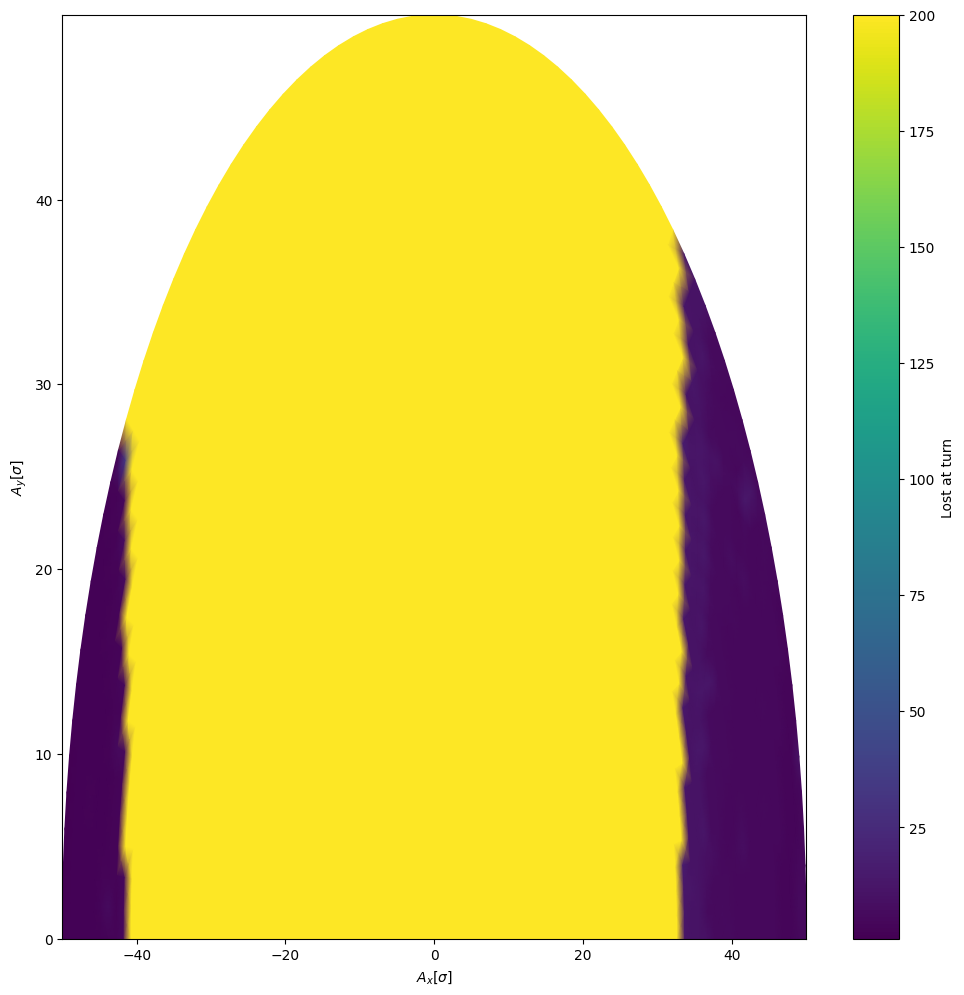

In [ ]:


plt.figure(2)
plt.pcolormesh(
    x_norm.reshape(n_r, n_theta), y_norm.reshape(n_r, n_theta),
    particles.at_turn.reshape(n_r, n_theta), shading='gouraud')
plt.xlabel(r'$A_x [\sigma]$')
plt.ylabel(r'$A_y [\sigma]$')
ax = plt.colorbar()
ax.set_label('Lost at turn')

plt.show()